# Idea 4 · Lesson 6 — Mutual attention & GNNExplainer

**xAI methods #1 and #3.** Two more views of the same trained model:

- **Mutual attention** — the model's own attention weights, summed per residue (what Sendin used, and what he cautioned is *not* a guaranteed-faithful explanation).
- **GNNExplainer** (Ying 2019) — learns a soft mask over nodes/edges that preserves the prediction; PyG ships it built-in.

We then ask whether the two agree. If three methods disagree (the Fazel 2025 finding on pLMs), a **consensus** may be more trustworthy than any one — which is exactly the hypothesis lesson 7 tests.

> **Run order matters.** These cells build on each other — run them top to bottom (*Run All*). Heavy steps (training, Integrated Gradients) are small by design but still compute; on a shared machine, run them when the box is idle.

## Setup

In [1]:
import os, sys
HERE = os.path.abspath("")
ROOT = HERE if os.path.isfile(os.path.join(HERE, "ig", "idea4_common.py")) \
    else os.path.dirname(HERE)
sys.path.insert(0, os.path.join(ROOT, "ig"))
DATA = os.path.join(ROOT, "data")
WEIGHTS = os.path.join(DATA, "idea4_struct2graph.pt")
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\plm-starter


In [2]:
from idea4_common import (load_or_train_demo, _gnnexplainer_saliency,
                          rank01, get_device)
import numpy as np, torch
import matplotlib.pyplot as plt
device = get_device(); print('device:', device)

device: cuda


In [3]:
model, samples = load_or_train_demo(WEIGHTS, hidden=32, device=device,
                                    cache_dir=DATA)
model = model.to(device).eval()
s0 = next(s for s in samples if not s['augmented'])
ga, gb = s0['ga'].to(device), s0['gb'].to(device)
print('explaining complex:', s0['name'])

explaining complex: 1brs:A-D


## Step 1 — Attention saliency

The mutual-attention matrix is (barnase × barstar). Summing each barnase residue's attention *to* barstar gives a per-residue saliency: how much this residue attends across the interface.

In [4]:
_ = model(ga, gb)  # populates model._cache['attn_ab']
attn = model._cache['attn_ab'].detach().cpu().numpy()  # (La, Ld)
attn_a = attn.sum(1)  # barnase residues
attn_d = attn.sum(0)  # barstar residues
print('attention saliency (barnase) shape:', attn_a.shape)

attention saliency (barnase) shape: (108,)


## Step 2 — GNNExplainer saliency

GNNExplainer expects a single graph→prediction signature, but our model takes a *pair* of graphs. The helper wraps it: it freezes the partner chain's embeddings and learns a node mask over *this* chain — so the explanation is conditional on the partner. (Documented design choice.)

In [5]:
h_b = model.encode(gb.x, gb.edge_index).detach()
h_a = model.encode(ga.x, ga.edge_index).detach()
gnnx_a = _gnnexplainer_saliency(model, ga.x, ga.edge_index, h_b, epochs=80)
gnnx_d = _gnnexplainer_saliency(model, gb.x, gb.edge_index, h_a, epochs=80)
print('GNNExplainer saliency (barnase) shape:', np.asarray(gnnx_a).shape)

GNNExplainer saliency (barnase) shape: (108,)


## Step 3 — Do the two methods agree?

Rank-normalise both to [0, 1] (they live on different scales) and correlate. Low agreement is the *motivation* for a consensus, not a bug — it echoes Fazel 2025: no single attribution method is reliable alone.

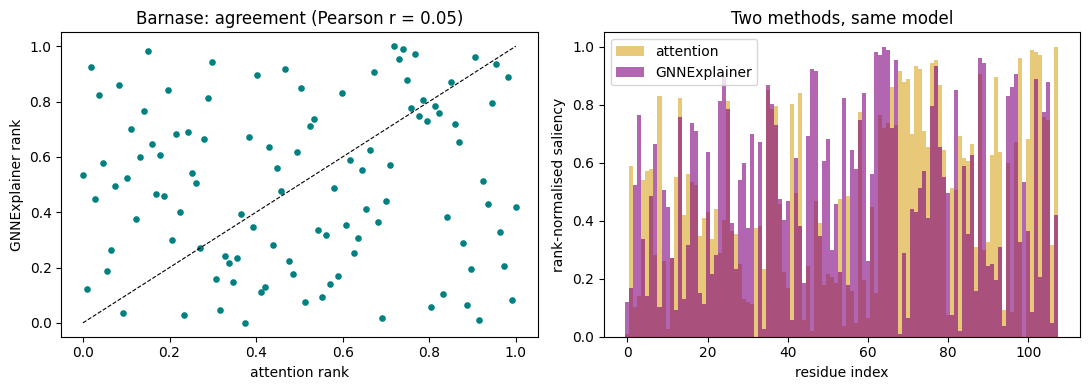

rank correlation barnase: 0.048


In [6]:
ra, rg = rank01(attn_a), rank01(gnnx_a)
rho = float(np.corrcoef(ra, rg)[0, 1])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(ra, rg, s=14, color='teal')
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
ax[0].set_xlabel('attention rank'); ax[0].set_ylabel('GNNExplainer rank')
ax[0].set_title(f'Barnase: agreement (Pearson r = {rho:.2f})')
ax[1].bar(range(len(ra)), ra, width=1.0, alpha=0.6, label='attention', color='goldenrod')
ax[1].bar(range(len(rg)), rg, width=1.0, alpha=0.6, label='GNNExplainer', color='purple')
ax[1].set_xlabel('residue index'); ax[1].set_ylabel('rank-normalised saliency')
ax[1].legend(); ax[1].set_title('Two methods, same model')
plt.tight_layout(); plt.show()
print(f'rank correlation barnase: {rho:.3f}')

## Recap

We now have all three single-method saliencies (IG from lesson 5, attention and GNNExplainer here). They don't fully agree — so which, if any, recovers the *experimentally measured* hotspots? **Lesson 7** pulls SKEMPI v2.0, builds the consensus, and runs the benchmark.